# (CNN) - Clasificador de Animales
### Clases: Ranas, Pájaros, Ballenas, Changos, Arañas


# 1. Importar Librerías

In [90]:
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Input, LeakyReLU,
    Rescaling
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.15.0


# 2. Cargar Imágenes del Dataset

**Estructura esperada de carpetas:**
```
C:\DatasetFinal\Dataset_Final
├── aranas
├── ballenas
├── changos
├── pajaros
└── ranas
```

In [92]:
DATASET_PATH = r"C:\DatasetFinal\Dataset_Final"

IMG_SIZE = (35, 35)
BATCH_SIZE = 64
SEED = 42

class_names = [
    'aranas',
    'ballenas',
    'changos',
    'pajaros',
    'ranas'
]
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    class_names=class_names,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    class_names=class_names,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

clases_nombres = class_names
nClasses = len(clases_nombres)

print("Clases:", clases_nombres)
print("Número de clases:", nClasses)

Found 99987 files belonging to 5 classes.
Using 79990 files for training.
Found 99987 files belonging to 5 classes.
Using 19997 files for validation.
Clases: ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']
Número de clases: 5


# 3. Verificar Equilibrio del Dataset

=== EQUILIBRIO DEL DATASET ===

aranas    : 20000
ballenas  : 20000
changos   : 20000
pajaros   : 20000
ranas     : 19987

Total: 99987 imágenes


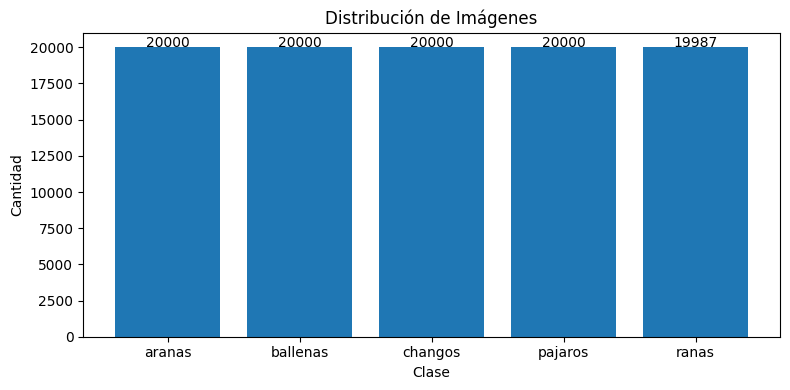

In [93]:
import os
import matplotlib.pyplot as plt

dircount = []

for clase in clases_nombres:

    folder = os.path.join(DATASET_PATH, clase)

    cantidad = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ])

    dircount.append(cantidad)

print("=== EQUILIBRIO DEL DATASET ===\n")

for clase, cantidad in zip(clases_nombres, dircount):
    print(f"{clase:<10}: {cantidad}")

print(f"\nTotal: {sum(dircount)} imágenes")

plt.figure(figsize=(8,4))
plt.bar(clases_nombres, dircount)

for i, v in enumerate(dircount):
    plt.text(i, v + 20, str(v), ha='center')

plt.title("Distribución de Imágenes")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.tight_layout()
plt.show()

# 4. Convertir a Matrices Numpy

In [94]:
# =========================================================
# INFORMACIÓN DEL DATASET
# =========================================================

print("Número de clases:", nClasses)

print("Clases:", clases_nombres)

print("Tamaño de imagen:", IMG_SIZE)

print("Batch size:", BATCH_SIZE)

# =============================================
# VER UN BATCH
# =============================================

for images_batch, labels_batch in train_ds.take(1):

    print("\nShape imágenes:", images_batch.shape)

    print("Shape labels:", labels_batch.shape)

    print("Canales RGB:", images_batch.shape[3])

    break

Número de clases: 5
Clases: ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']
Tamaño de imagen: (35, 35)
Batch size: 64

Shape imágenes: (64, 35, 35, 3)
Shape labels: (64, 5)
Canales RGB: 3


# 5. Dividir en Sets de Entrenamiento y Prueba

In [96]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
valid_batches = tf.data.experimental.cardinality(valid_ds).numpy()

print(f'Batches entrenamiento: {train_batches}')
print(f'Batches validación:    {valid_batches}')
print(f'Batch size:            {BATCH_SIZE}')

for images_batch, labels_batch in train_ds.take(1):
    print("\nShape imágenes:", images_batch.shape)
    print("Shape labels:", labels_batch.shape)
    break

Batches entrenamiento: 1250
Batches validación:    313
Batch size:            64

Shape imágenes: (64, 35, 35, 3)
Shape labels: (64, 5)


# 6. Visualizar Ejemplos del Dataset

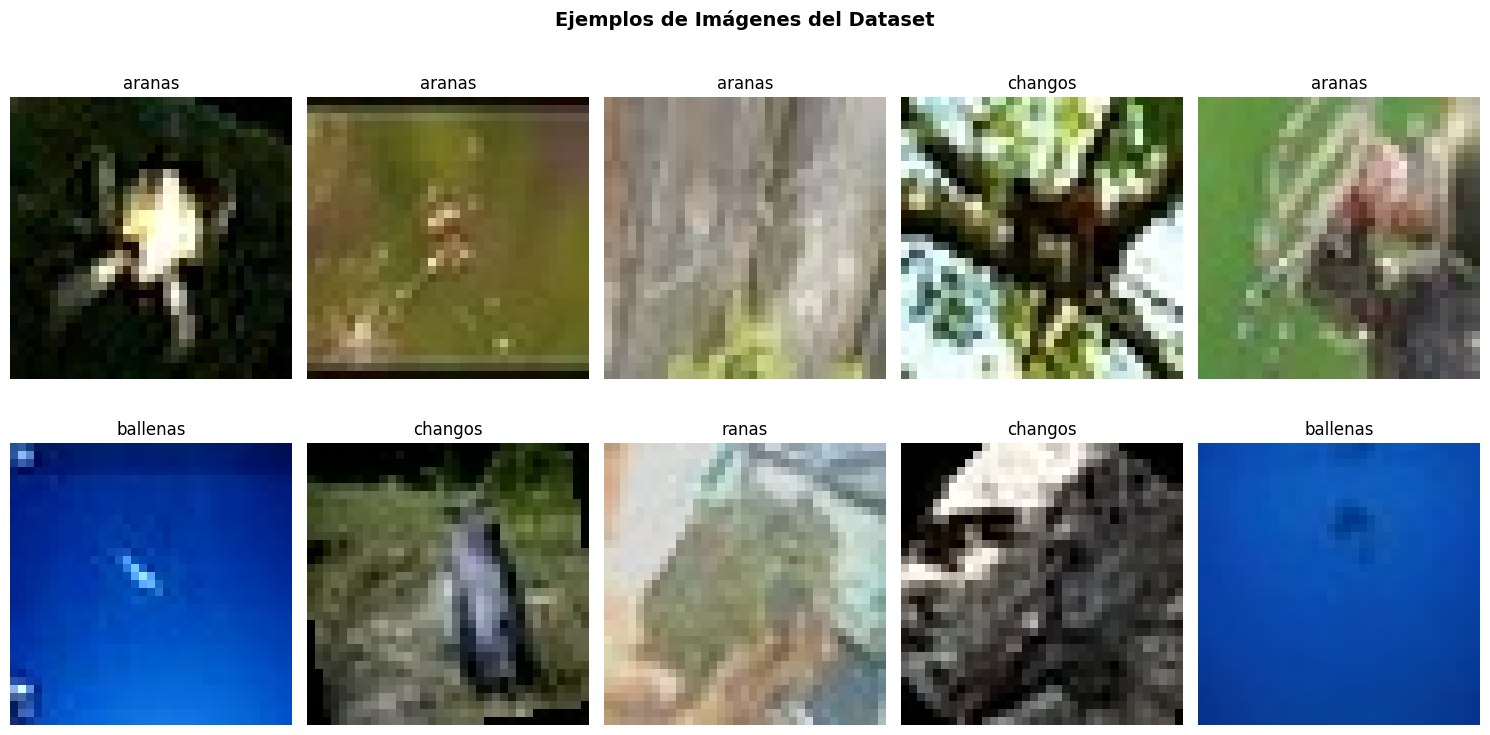

In [97]:
# =========================================================
# VISUALIZAR EJEMPLOS DEL DATASET
# =========================================================

plt.figure(figsize=(15, 8))

for images_batch, labels_batch in train_ds.take(1):

    for i in range(10):

        ax = plt.subplot(2, 5, i + 1)

        plt.imshow(images_batch[i].numpy().astype("uint8"))

        clase_idx = np.argmax(labels_batch[i])

        plt.title(clases_nombres[clase_idx])

        plt.axis("off")

plt.suptitle(
    'Ejemplos de Imágenes del Dataset',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# 7. Preprocesar las Imágenes (Normalización)

In [98]:
# =========================================================
# NORMALIZACIÓN AUTOMÁTICA
# =========================================================

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

valid_ds = valid_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

# =========================================================
# OPTIMIZACIÓN DE RENDIMIENTO
# =========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Normalización aplicada correctamente")

✅ Normalización aplicada correctamente


# 8. Encoding de Etiquetas

In [99]:
# =========================================================
# VERIFICAR ONE HOT ENCODING
# =========================================================

for images_batch, labels_batch in train_ds.take(1):

    print("Shape labels:", labels_batch.shape)

    print("\nEjemplo one-hot:")

    print(labels_batch[0].numpy())

    clase_idx = np.argmax(labels_batch[0].numpy())

    print("Clase:", clases_nombres[clase_idx])

    break

print("\n✅ One-Hot Encoding automático correcto")

Shape labels: (64, 5)

Ejemplo one-hot:
[1. 0. 0. 0. 0.]
Clase: aranas

✅ One-Hot Encoding automático correcto


# 9. Crear Set de Validación

In [100]:
# =========================================================
# INFORMACIÓN FINAL DEL DATASET
# =========================================================

print("Número de clases:", nClasses)

print("Clases:", clases_nombres)

print("Tamaño imágenes:", IMG_SIZE)

print("Batch size:", BATCH_SIZE)

# =============================================
# CONTAR BATCHES
# =============================================

train_batches = tf.data.experimental.cardinality(train_ds).numpy()

valid_batches = tf.data.experimental.cardinality(valid_ds).numpy()

print("\nBatches entrenamiento:", train_batches)

print("Batches validación:", valid_batches)

# =============================================
# VERIFICAR UN BATCH
# =============================================

for images_batch, labels_batch in train_ds.take(1):

    print("\nShape imágenes:", images_batch.shape)

    print("Shape labels:", labels_batch.shape)

    break

Número de clases: 5
Clases: ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']
Tamaño imágenes: (35, 35)
Batch size: 64

Batches entrenamiento: 1250
Batches validación: 313

Shape imágenes: (64, 35, 35, 3)
Shape labels: (64, 5)


# 10. Parámetros de Entrenamiento

In [69]:
# 10. Parámetros de Entrenamiento

INIT_LR = 1e-3

epochs = 35

batch_size = 64

# 11. Crear el Modelo CNN 


In [ ]:
# =============================================
#   ARQUITECTURA CNN
# =============================================

animal_model = Sequential(name='CNN_Animales_Color')

animal_model.add(Input(shape=(35, 35, 3)))

#CAPA CONVOLUCIONAL 1: busca características simple como bordes, lineas, colores
animal_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
animal_model.add(BatchNormalization())
animal_model.add(MaxPooling2D((2, 2))) #reduce el tamaño de la imagen el MAX POOLING
animal_model.add(Dropout(0.25))

#CAPA CONVOLUCIONAL 2: detecta formas
animal_model.add
(Conv2D(64, (3, 3), activation='relu', padding='same'))
animal_model.add(BatchNormalization())
animal_model.add(MaxPooling2D((2, 2)))
animal_model.add(Dropout(0.25))

# CAPA CONVOLUCIONAL 3: detecta patrones más completos del animal
animal_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
animal_model.add(BatchNormalization())
animal_model.add(MaxPooling2D((2, 2)))
animal_model.add(Dropout(0.30))

#CAPAS DENSAS: Combina toda la información aprendida
animal_model.add(Flatten())
animal_model.add(Dense(256, activation='relu'))
animal_model.add(BatchNormalization())
animal_model.add(Dropout(0.5))

#SALIDA
animal_model.add(Dense(nClasses, activation='softmax'))

animal_model.summary()

Model: "CNN_Animales_Color"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 35, 35, 32)        896       
                                                                 
 batch_normalization_12 (Ba  (None, 35, 35, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 17, 17, 32)        0         
 g2D)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 17, 17, 32)        0         
                                                                 
 conv2d_10 (Conv2D)          (None, 17, 17, 64)        18496     
                                                                 
 batch_normalization_13 (Ba  (None, 17, 17, 64) 

# 12. Compilar el Modelo

In [102]:
# =============================================
# COMPILAR MODELO
# =============================================

animal_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INIT_LR
    ),
    metrics=['accuracy']
)

print('✅ Modelo compilado correctamente')

✅ Modelo compilado correctamente


# 13. Entrenar el Modelo

> ⏳ Puede tardar varios minutos. Se guarda automáticamente el **mejor** modelo.

In [ ]:
checkpoint = ModelCheckpoint(
    'modelo_animales_final_35epocas.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

animal_train = animal_model.fit( #aquí aprende comparando la prediccion con la respuesta y ajusta pesos
    train_ds,
    epochs=35,
    validation_data=valid_ds,
    callbacks=[checkpoint],
    verbose=1
)

print('\n✅ Entrenamiento finalizado')

Epoch 1/35
1250/1250 [==============================] - ETA: 0s - loss: 0.9880 - accuracy: 0.6160
Epoch 1: val_accuracy improved from -inf to 0.69070, saving model to modelo_animales_final_35epocas.keras
1250/1250 [==============================] - 92s 70ms/step - loss: 0.9880 - accuracy: 0.6160 - val_loss: 0.7652 - val_accuracy: 0.6907
Epoch 2/35
1250/1250 [==============================] - ETA: 0s - loss: 0.7072 - accuracy: 0.7259
Epoch 2: val_accuracy improved from 0.69070 to 0.77052, saving model to modelo_animales_final_35epocas.keras
1250/1250 [==============================] - 82s 66ms/step - loss: 0.7072 - accuracy: 0.7259 - val_loss: 0.5855 - val_accuracy: 0.7705
Epoch 3/35
1250/1250 [==============================] - ETA: 0s - loss: 0.6319 - accuracy: 0.7552
Epoch 3: val_accuracy did not improve from 0.77052
1250/1250 [==============================] - 85s 68ms/step - loss: 0.6319 - accuracy: 0.7552 - val_loss: 0.5987 - val_accuracy: 0.7620
Epoch 4/35
1250/1250 [=============

# 14. Evaluar el Modelo

In [104]:
# =============================================
# EVALUACIÓN FINAL
# =============================================

test_eval = animal_model.evaluate(
    valid_ds,
    verbose=1
)

print(f'\nPérdida (Loss):   {test_eval[0]:.4f}')

print(f'Precisión (Acc):  {test_eval[1] * 100:.2f}%')

313/313 [==============================] - 5s 17ms/step - loss: 0.4018 - accuracy: 0.8438

Pérdida (Loss):   0.4018
Precisión (Acc):  84.38%


# 15. Gráficas de Entrenamiento

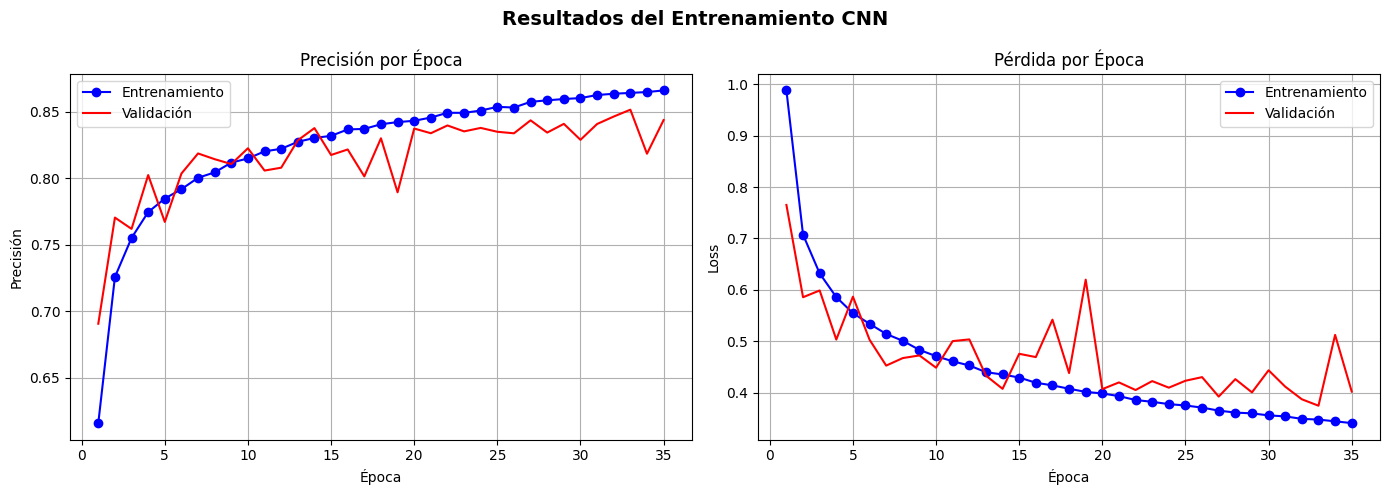

In [105]:
accuracy = animal_train.history['accuracy']
val_accuracy = animal_train.history['val_accuracy']

loss = animal_train.history['loss']
val_loss = animal_train.history['val_loss']

epocas_rango = range(1, len(accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epocas_rango, accuracy, 'bo-', label='Entrenamiento')
ax1.plot(epocas_rango, val_accuracy, 'r-', label='Validación')

ax1.set_title('Precisión por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')

ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(epocas_rango, loss, 'bo-', label='Entrenamiento')
ax2.plot(epocas_rango, val_loss, 'r-', label='Validación')

ax2.set_title('Pérdida por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')

ax2.legend()
ax2.grid(True)

plt.suptitle('Resultados del Entrenamiento CNN', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 16. Reporte de Clasificación

In [106]:
imagenes = []
labels_reales = []

for images_batch, labels_batch in valid_ds:
    imagenes.append(images_batch.numpy())
    labels_reales.append(labels_batch.numpy())

imagenes = np.concatenate(imagenes, axis=0)
labels_reales = np.concatenate(labels_reales, axis=0)

true_classes = np.argmax(labels_reales, axis=1)

predicted_probs = animal_model.predict(imagenes, verbose=1)
predicted_classes = np.argmax(predicted_probs, axis=1)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=clases_nombres,
    zero_division=0
))

625/625 [==============================] - 6s 9ms/step
              precision    recall  f1-score   support

      aranas       0.79      0.85      0.82      4089
    ballenas       0.94      0.96      0.95      4008
     changos       0.75      0.83      0.79      3951
     pajaros       0.92      0.80      0.86      3933
       ranas       0.84      0.77      0.80      4016

    accuracy                           0.84     19997
   macro avg       0.85      0.84      0.84     19997
weighted avg       0.85      0.84      0.84     19997



=== MATRIZ DE CONFUSIÓN ===
               Pred aranas  Pred ballenas  Pred changos  Pred pajaros  \
Real aranas           3468             57           291            41   
Real ballenas           64           3846            57            30   
Real changos           254             40          3295           133   
Real pajaros           208             98           337          3159   
Real ranas             423             38           396            53   

               Pred ranas  
Real aranas           232  
Real ballenas          11  
Real changos          229  
Real pajaros          131  
Real ranas           3106  


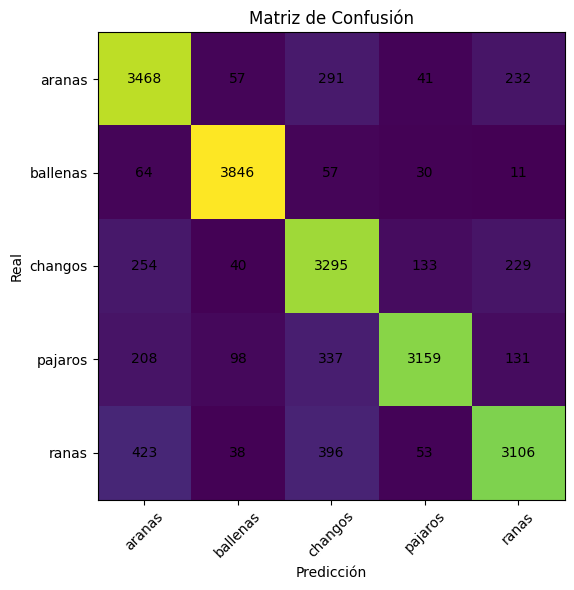


=== CONTEO DE PREDICCIONES ===
aranas: 4417
ballenas: 4079
changos: 4376
pajaros: 3416
ranas: 3709


In [107]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# MATRIZ DE CONFUSIÓN
# =============================================

cm = confusion_matrix(true_classes, predicted_classes)

df_cm = pd.DataFrame(
    cm,
    index=[f"Real {c}" for c in clases_nombres],
    columns=[f"Pred {c}" for c in clases_nombres]
)

print("=== MATRIZ DE CONFUSIÓN ===")
print(df_cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.xticks(range(len(clases_nombres)), clases_nombres, rotation=45)
plt.yticks(range(len(clases_nombres)), clases_nombres)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

for i in range(len(clases_nombres)):
    for j in range(len(clases_nombres)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# =============================================
# CONTEO DE PREDICCIONES
# =============================================

unique, counts = np.unique(predicted_classes, return_counts=True)

print("\n=== CONTEO DE PREDICCIONES ===")
for idx, count in zip(unique, counts):
    print(f"{clases_nombres[idx]}: {count}")

# 17. Ver Aciertos y Errores

625/625 [==============================] - 5s 8ms/step
Correctas:   16889
Incorrectas: 3108


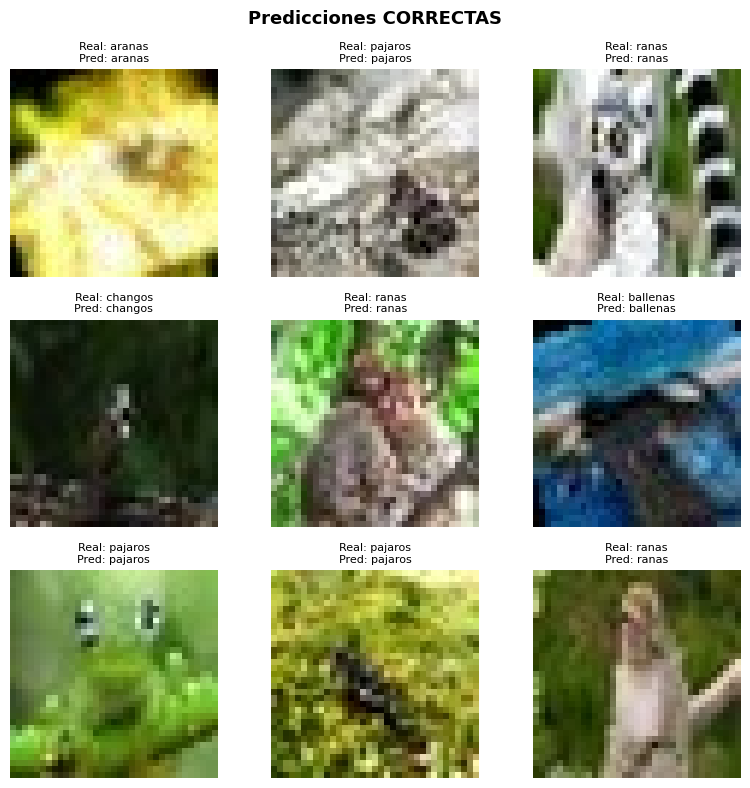

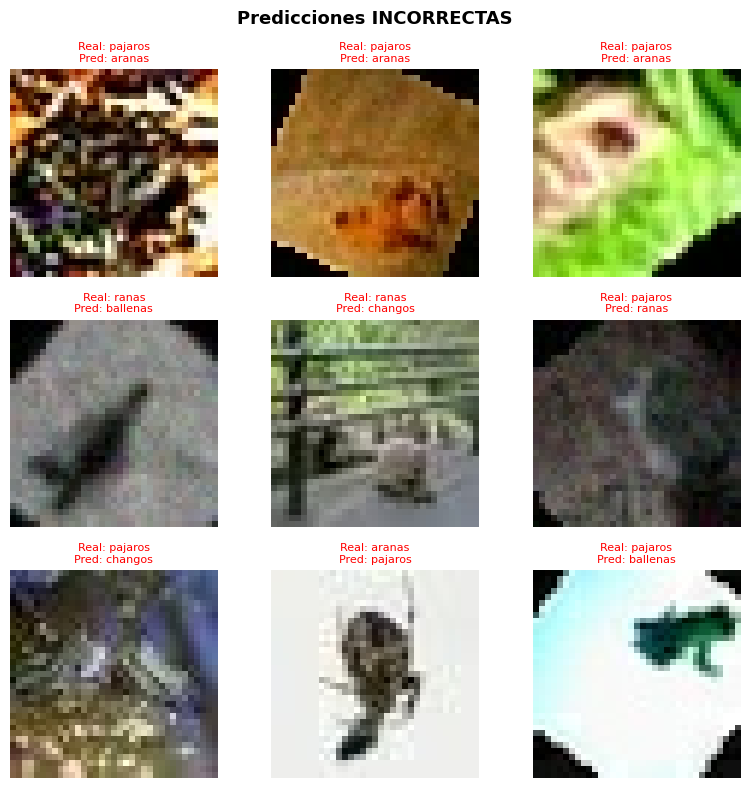

In [77]:
# =============================================
# GUARDAR IMÁGENES, ETIQUETAS Y PREDICCIONES
# =============================================

test_images = []

true_classes = []

for images_batch, labels_batch in valid_ds:

    test_images.extend(images_batch.numpy())

    true_classes.extend(
        np.argmax(labels_batch.numpy(), axis=1)
    )

test_images = np.array(test_images)

true_classes = np.array(true_classes)

# =============================================
# PREDICCIONES
# =============================================

predicted_probs = animal_model.predict(
    test_images,
    verbose=1
)

predicted_classes = np.argmax(
    predicted_probs,
    axis=1
)

# =============================================
# COMPARAR PREDICCIONES
# =============================================

correct = np.where(
    predicted_classes == true_classes
)[0]

incorrect = np.where(
    predicted_classes != true_classes
)[0]

print(f'Correctas:   {len(correct)}')

print(f'Incorrectas: {len(incorrect)}')

# =============================================
# PREDICCIONES CORRECTAS
# =============================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(8, 8)
)

fig.suptitle(
    'Predicciones CORRECTAS',
    fontsize=13,
    fontweight='bold'
)

for i, idx in enumerate(correct[:9]):

    ax = axes[i // 3, i % 3]

    ax.imshow(test_images[idx])

    ax.set_title(
        f'Real: {clases_nombres[true_classes[idx]]}\n'
        f'Pred: {clases_nombres[predicted_classes[idx]]}',
        fontsize=8
    )

    ax.axis('off')

plt.tight_layout()

plt.show()

# =============================================
# PREDICCIONES INCORRECTAS
# =============================================

if len(incorrect) > 0:

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(8, 8)
    )

    fig.suptitle(
        'Predicciones INCORRECTAS',
        fontsize=13,
        fontweight='bold'
    )

    for i, idx in enumerate(incorrect[:9]):

        ax = axes[i // 3, i % 3]

        ax.imshow(test_images[idx])

        ax.set_title(
            f'Real: {clases_nombres[true_classes[idx]]}\n'
            f'Pred: {clases_nombres[predicted_classes[idx]]}',
            fontsize=8,
            color='red'
        )

        ax.axis('off')

    plt.tight_layout()

    plt.show()

---
# ════════════════════════════════════════
# DESDE AQUÍ SIN REENTRENAR MODELO
# ════════════════════════════════════════

# 18. Cargar Modelo Guardado

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

animal_model = load_model('modelo_animales_final_35epocas.keras') #aquí ya se carga todo lo aprendido

clases_nombres = ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']

print('✅ Modelo cargado correctamente')
print('✅ Ejecuta la siguiente celda para identificar un animal')




✅ Modelo cargado correctamente
✅ Ejecuta la siguiente celda para identificar un animal


# 19. dentificar nuevas imagenes


8 imagen(es) seleccionada(s)

Imagen 1: ar2.jpg
Animal: ARANAS | Confianza: 88.4%
Probabilidades:
aranas    :  88.4% ██████████████████████████
ballenas  :   0.1% 
changos   :   0.1% 
pajaros   :  11.1% ███
ranas     :   0.3% 

Imagen 2: ar1.jpg
Animal: ARANAS | Confianza: 57.7%
Probabilidades:
aranas    :  57.7% █████████████████
ballenas  :   0.1% 
changos   :   0.5% 
pajaros   :  40.8% ████████████
ranas     :   0.9% 

Imagen 3: Sindo.jpg
Animal: ARANAS | Confianza: 99.8%
Probabilidades:
aranas    :  99.8% █████████████████████████████
ballenas  :   0.0% 
changos   :   0.0% 
pajaros   :   0.0% 
ranas     :   0.1% 

Imagen 4: ima1ges.jpg
Animal: ARANAS | Confianza: 82.6%
Probabilidades:
aranas    :  82.6% ████████████████████████
ballenas  :   0.0% 
changos   :   0.0% 
pajaros   :  16.9% █████
ranas     :   0.5% 

Imagen 5: So.jpg
Animal: ARANAS | Confianza: 88.4%
Probabilidades:
aranas    :  88.4% ██████████████████████████
ballenas  :   0.1% 
changos   :   0.1% 
pajaros   :  11.1% 

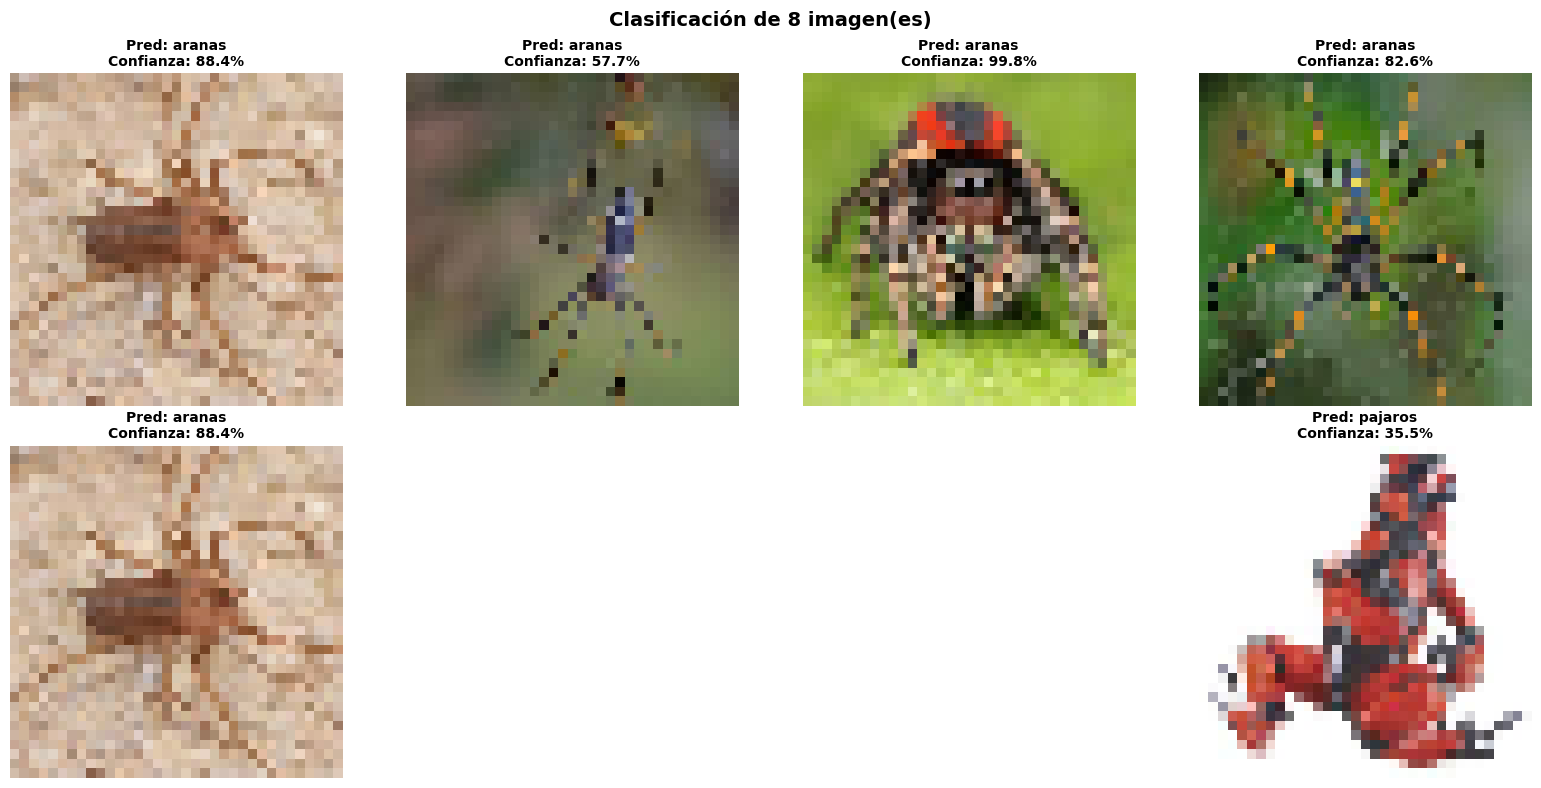

In [21]:
import tkinter as tk
from tkinter import filedialog
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

clases_nombres = ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']

root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

mis_imagenes = filedialog.askopenfilenames(
    title="Selecciona imágenes (Ctrl+Click para varias)",
    filetypes=[
        ("Imágenes", "*.jpg *.jpeg *.png *.bmp *.tiff"),
        ("Todos los archivos", "*.*")
    ],
    multiple=True
)

root.destroy()

if not mis_imagenes:
    print("No seleccionaste ninguna imagen.")
else:
    print(f"{len(mis_imagenes)} imagen(es) seleccionada(s)\n")

    n = len(mis_imagenes)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if n == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    for i, ruta in enumerate(mis_imagenes):
        img = cv2.imread(ruta)

        if img is None:
            print(f"No se pudo leer: {ruta}")
            axes[i].axis('off')
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (35, 35))

        img_array = img_resized.astype('float32') / 255.0
        img_array = img_array.reshape(1, 35, 35, 3)

        prediccion = animal_model.predict(img_array, verbose=0)
        clase_idx = np.argmax(prediccion)
        confianza = prediccion[0][clase_idx] * 100

        axes[i].imshow(img_resized)
        axes[i].set_title(
            f'Pred: {clases_nombres[clase_idx]}\nConfianza: {confianza:.1f}%',
            fontsize=10,
            fontweight='bold'
        )
        axes[i].axis('off')

        print(f'Imagen {i+1}: {os.path.basename(ruta)}')
        print(f'Animal: {clases_nombres[clase_idx].upper()} | Confianza: {confianza:.1f}%')
        print('Probabilidades:')

        for clase, prob in zip(clases_nombres, prediccion[0]):
            barra = '█' * int(prob * 30)
            print(f'{clase:<10}: {prob*100:5.1f}% {barra}')

        print()

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Clasificación de {n} imagen(es)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()